## Capstone 1
## Forest Cover Type Project
## Uyenmy Nguyen, Citlali Concha
## **Reserach Question:** What would be the type tree that grow best according to the surrounding charateristic of a certain area?

## 1. Load the dataset

In [ ]:
# import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the dataset using pandas
fct = pd.read_csv('Forest Cover Type Project.csv')
fct.head(10) # load the first 10 rows

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
5,2579,132,6,300,-15,67,230,237,140,6031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
6,2606,45,7,270,5,633,222,225,138,6256,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
7,2605,49,4,234,7,573,222,230,144,6228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
8,2617,45,9,240,56,666,223,221,133,6244,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
9,2612,59,10,247,11,636,228,219,124,6230,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


## 2. EDA

In [ ]:
# Chack for rows and columns count
fct.shape

(137782, 55)

In [ ]:
# check on all data types
fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137782 entries, 0 to 137781
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           137782 non-null  int64  
 1   Aspect                              137782 non-null  int64  
 2   Slope                               137782 non-null  int64  
 3   Horizontal_Distance_To_Hydrology    137782 non-null  int64  
 4   Vertical_Distance_To_Hydrology      137782 non-null  int64  
 5   Horizontal_Distance_To_Roadways     137782 non-null  int64  
 6   Hillshade_9am                       137782 non-null  int64  
 7   Hillshade_Noon                      137782 non-null  int64  
 8   Hillshade_3pm                       137782 non-null  int64  
 9   Horizontal_Distance_To_Fire_Points  137782 non-null  int64  
 10  Wilderness_Area1                    137781 non-null  float64
 11  Wilderness_Area2          

* All columns are interger values!
* No need to change dtype before EDA visualize distribution!

In [ ]:
# check on all missing values in dataset
print('All Missing Values per Column:')
print(fct.isnull().sum())

All Missing Values per Column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      1
Wilderness_Area2                      1
Wilderness_Area3                      1
Wilderness_Area4                      1
Soil_Type1                            1
Soil_Type2                            1
Soil_Type3                            1
Soil_Type4                            1
Soil_Type5                            1
Soil_Type6                            1
Soil_Type7                            1
Soil_Type8                            1
Soil_Type9                            1
Soil_Type10                           1
Soil_Type

There are no missing values appear in the dataset!

<Axes: >

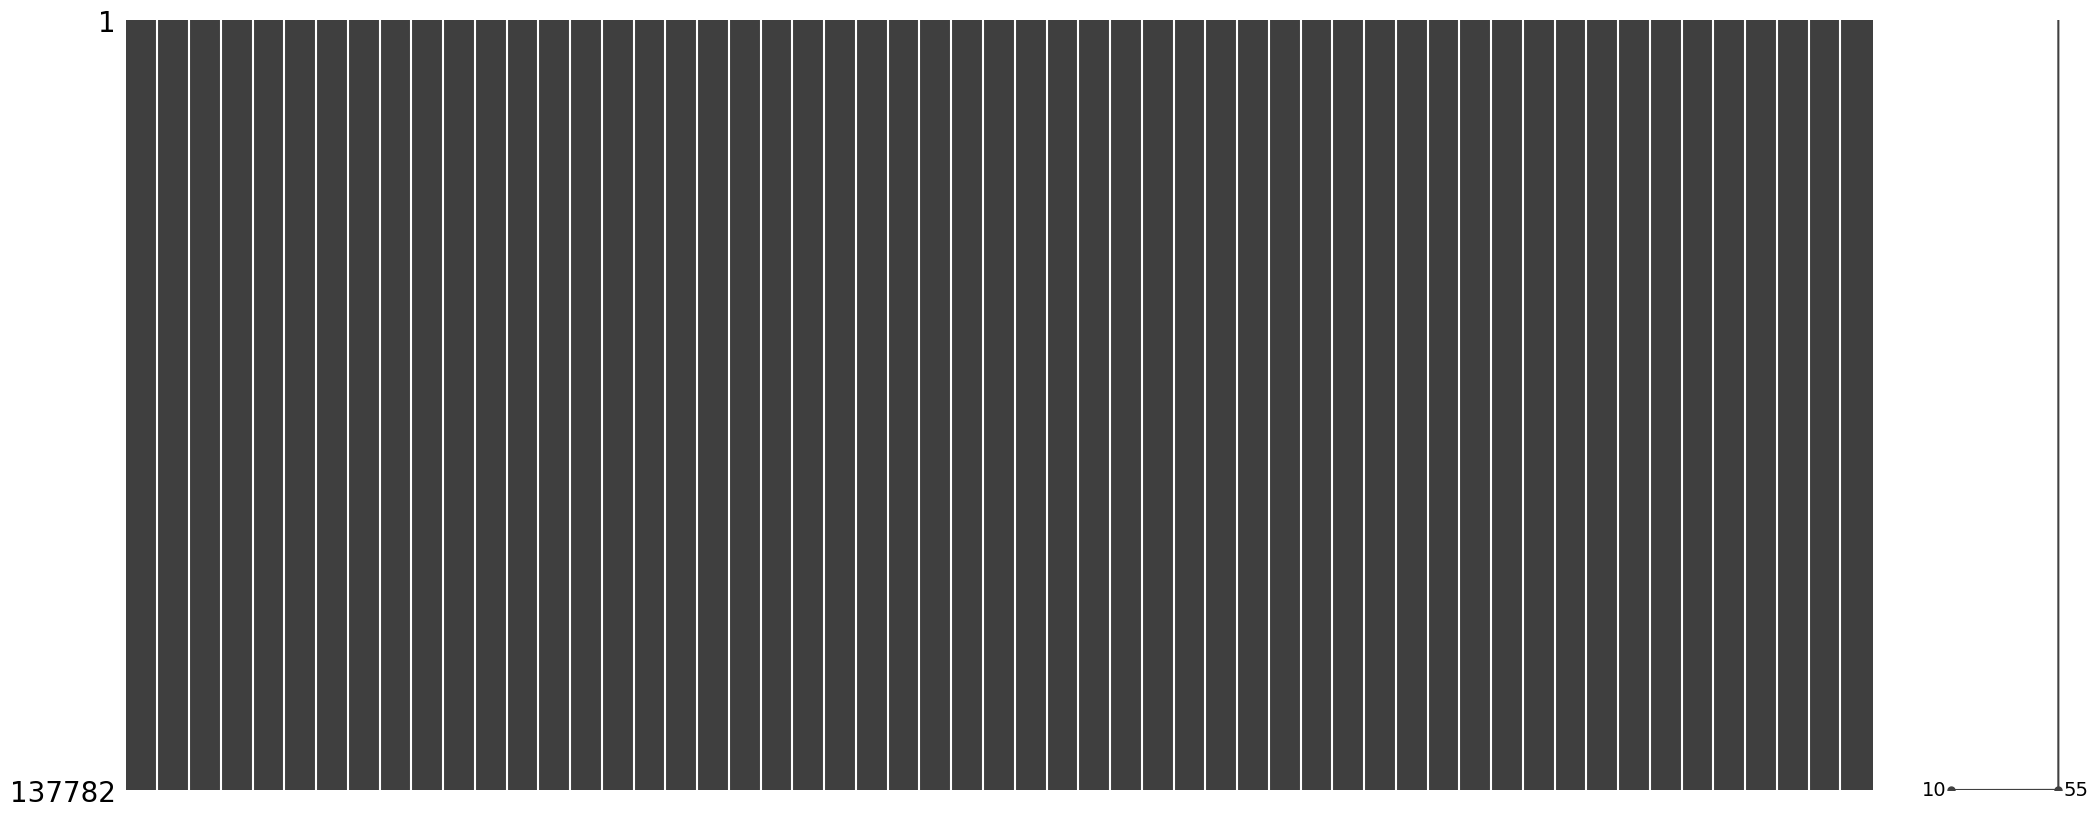

In [ ]:
# visualize missingness using msno
# (optional since there are no missingness show above)
import missingno as msno
msno.matrix(fct)

* dark: values present
* white space: missingness
* Conclusion: no missingness appear!

In [ ]:
# check for duplicates
print('Duplicate:', fct.duplicated().sum())

Duplicate: 0


In [ ]:
# check for all statistical informations:
fct.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,137782.000000,137782.000000,137782.000000,137782.000000,137782.000000,137782.000000,137782.000000,137782.000000,137782.000000,137782.000000,...,137781.000000,137781.000000,137781.000000,137781.000000,137781.000000,137781.000000,137781.000000,137781.000000,137781.000000,137781.000000
mean,2869.286445,140.795989,11.952193,252.022136,34.557584,3290.038046,217.459298,224.914314,139.683892,3125.011714,...,0.005008,0.004471,0.000160,0.000740,0.000073,0.000247,0.005828,0.008782,0.005342,2.037008
std,212.862096,107.228392,6.353934,193.159713,41.163397,1704.162699,21.520207,16.216383,31.230727,1769.511160,...,0.070590,0.066715,0.012635,0.027199,0.008519,0.015707,0.076119,0.093301,0.072892,1.059612
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2740.000000,54.000000,7.000000,95.000000,7.000000,1785.000000,207.000000,216.000000,121.000000,1680.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,2905.000000,109.000000,11.000000,212.000000,23.000000,3392.000000,222.000000,227.000000,139.000000,2812.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,2998.000000,214.000000,15.000000,362.000000,51.000000,4665.000000,232.000000,236.000000,159.000000,4586.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


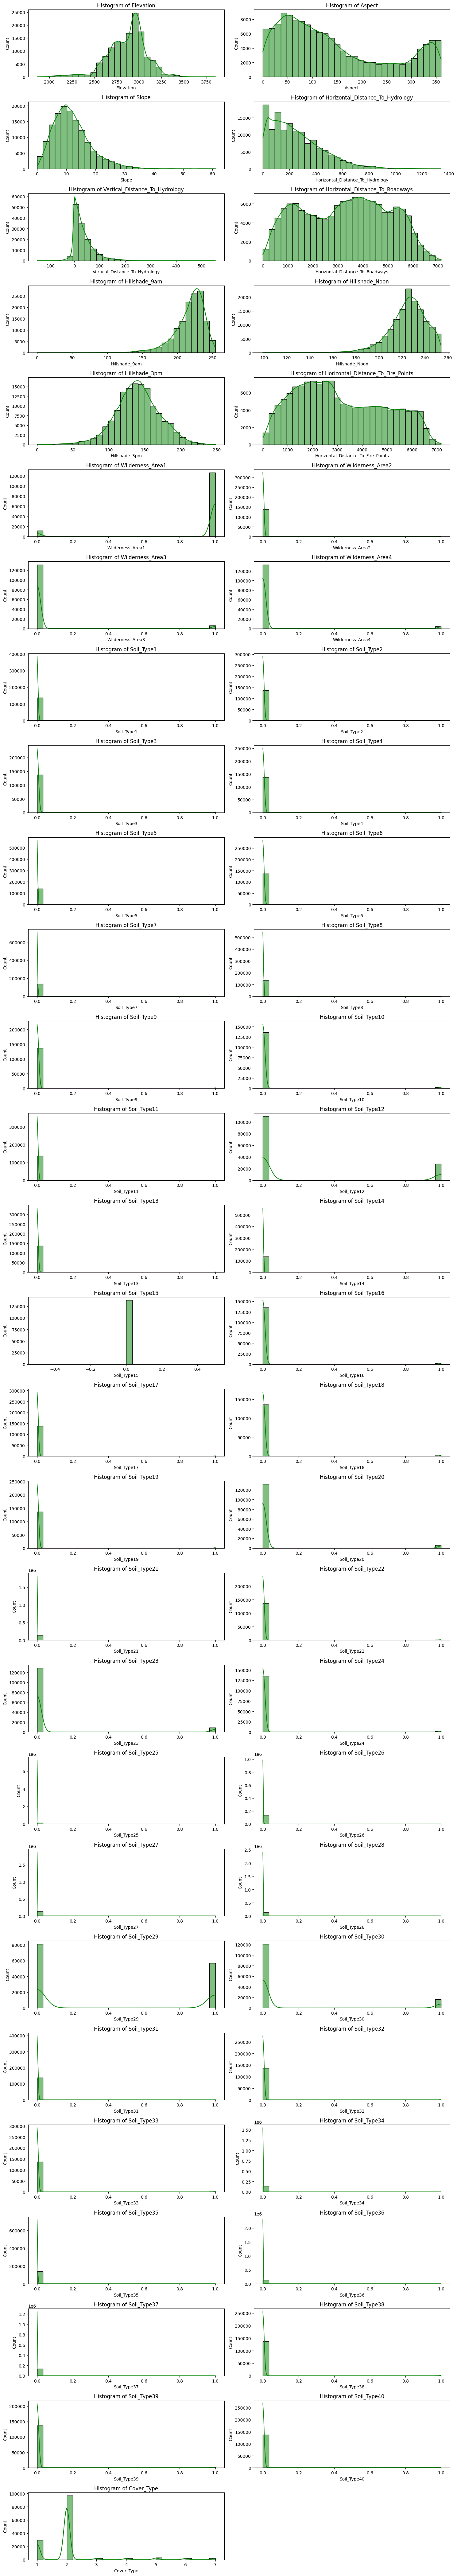

In [ ]:
# Using histogram/bar graph visualization
cols = fct.columns
n_features = len(cols)

# Calculate the number of rows needed based on the number of features and columns per row
n_cols_per_row = 2
n_rows = (n_features + n_cols_per_row - 1) // n_cols_per_row # Use integer division and ceiling

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(fct[col], bins=30, kde=True, ax=axes[i], color="green")
    axes[i].set_title(f"Histogram of {col}")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

* Personally I think histogram would be the best choice to visualize the distribution in each column! It helps define the best characteristic of each catergory such as skewnes, outliers, etc.
* Cover_Type is the Target Variable!!
* Challenge: Since this is a large dataset, it took a long time to visualize all of the histogram distributions.

In [ ]:
# check on value count of each target 'Cover Type' value
fct['Cover_Type'].value_counts()

,count
Cover_Type,
2.0,96752
1.0,29497
5.0,2892
7.0,2160
3.0,2160
6.0,2160
4.0,2160


## 3. Train-test-split

In [ ]:
# train-test-split
from sklearn.model_selection import train_test_split

# Drop rows with missing values in 'Cover_Type'
fct_cleaned = fct.dropna(subset=['Cover_Type'])

X = fct_cleaned.drop('Cover_Type', axis=1)
y = fct_cleaned['Cover_Type']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

print('\nTrain class distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest class distribution:')
print(y_test.value_counts(normalize=True))

(110224, 54)
(27557, 54)
(110224,)
(27557,)

Train class distribution:
Cover_Type
2.0    0.702161
1.0    0.213874
5.0    0.021012
7.0    0.015922
4.0    0.015759
3.0    0.015741
6.0    0.015532
Name: proportion, dtype: float64

Test class distribution:
Cover_Type
2.0    0.702435
1.0    0.214936
5.0    0.020902
6.0    0.016257
3.0    0.015423
4.0    0.015350
7.0    0.014697
Name: proportion, dtype: float64


## 4. Baseline Models (before tuning)

In [ ]:
# Import neccessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DECISION TREE MODEL

In [ ]:
# DECISION TREE MODEL
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
dt_y_pred = dt_model.predict(x_test)

# classification
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_y_pred))
print('Classification Report:')
print(classification_report(y_test, dt_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, dt_y_pred))

Decision Tree Accuracy: 0.9387451464237762
Classification Report:
              precision    recall  f1-score   support

         1.0       0.90      0.89      0.89      5923
         2.0       0.96      0.97      0.96     19357
         3.0       0.76      0.79      0.77       425
         4.0       0.89      0.91      0.90       423
         5.0       0.84      0.82      0.83       576
         6.0       0.82      0.78      0.80       448
         7.0       0.88      0.91      0.90       405

    accuracy                           0.94     27557
   macro avg       0.86      0.87      0.86     27557
weighted avg       0.94      0.94      0.94     27557


Confusion Matrix:
[[ 5270   601     1     0     5     2    44]
 [  569 18688    14     0    73     7     6]
 [    1     5   335    26     9    49     0]
 [    0     0    25   384     0    14     0]
 [    7    83     7     0   474     5     0]
 [    4    10    61    21     4   348     0]
 [   31     4     0     0     0     0   370]]


* Overall it performs very well: ~93.9% accuracy and weighted F1 ≈ 0.94. That means the features in this dataset separate the cover types strongly, and a single tree already captures most of the signal.
* Performance by class is solid for the big groups—Types 1 and 2 have F1 ≈ 0.92 and 0.96 with large support—so the model is especially reliable on the majority classes.
* The smaller classes (5, 6, 7) are a bit harder: F1s around 0.85–0.91 with recalls 0.84–0.92. The confusion matrix shows the main mix-ups are 1 ↔ 2, 3 ↔ 6, and some drift of Type 5 into 2/3/4. Those are likely ecologically similar in the feature space (slope/soil/elevation combinations), so the tree splits can blur those boundaries.
* **Conclusion:** The dataset is highly predictable with a simple model, but there’s mild class-imbalance/overlap affecting minority types. If you want to push recall/F1 for Types 5–6–7, try (a) an ensemble (Random Forest/Gradient Boosting) to reduce variance, and/or (b) class weights or light resampling to give minority classes more influence. That should tighten the confusions (esp. 3 vs 6, 1 vs 2) without sacrificing overall accuracy.

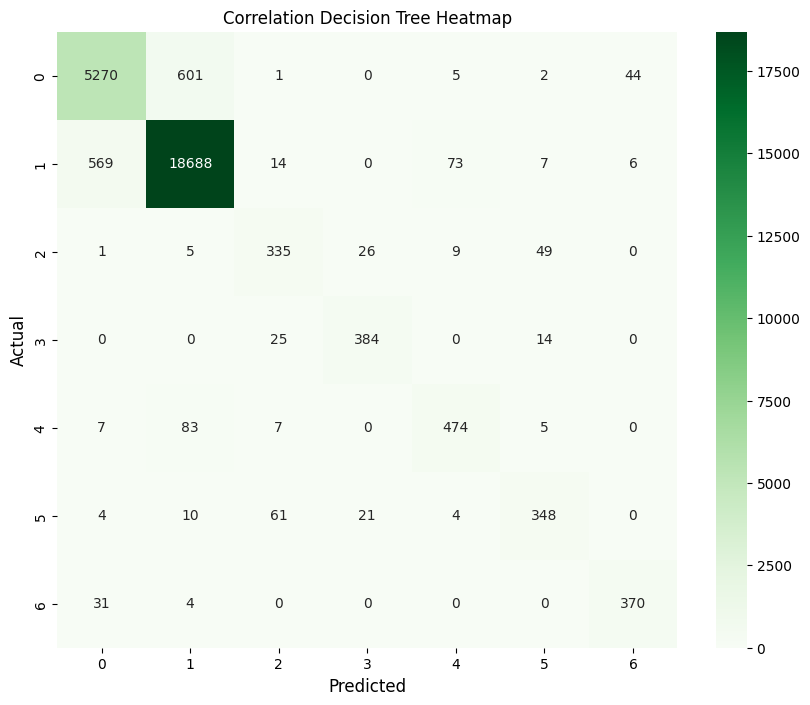

In [ ]:
# visualize decision tree model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, dt_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Decision Tree Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

* The decision tree does a solid job on Forest Cover Type, about 94% accuracy / weighted F1 ≈ 0.94—so the features clearly separate most classes. Most errors come from “look-alike” pairs, mainly Type 0 ↔ Type 1 and Type 2 ↔ Type 5 (plus a little 2 ↔ 3), and the smaller classes (5, 6, 7) have slightly lower recall. In short, the dataset is highly predictable with a single tree, but class overlap and minor imbalance cause those specific mix-ups. If I were improving this, I’d move to an ensemble (Random Forest or Gradient Boosting) and add class weights/oversampling for the small classes; that should clean up the confusion without hurting the strong overall score.

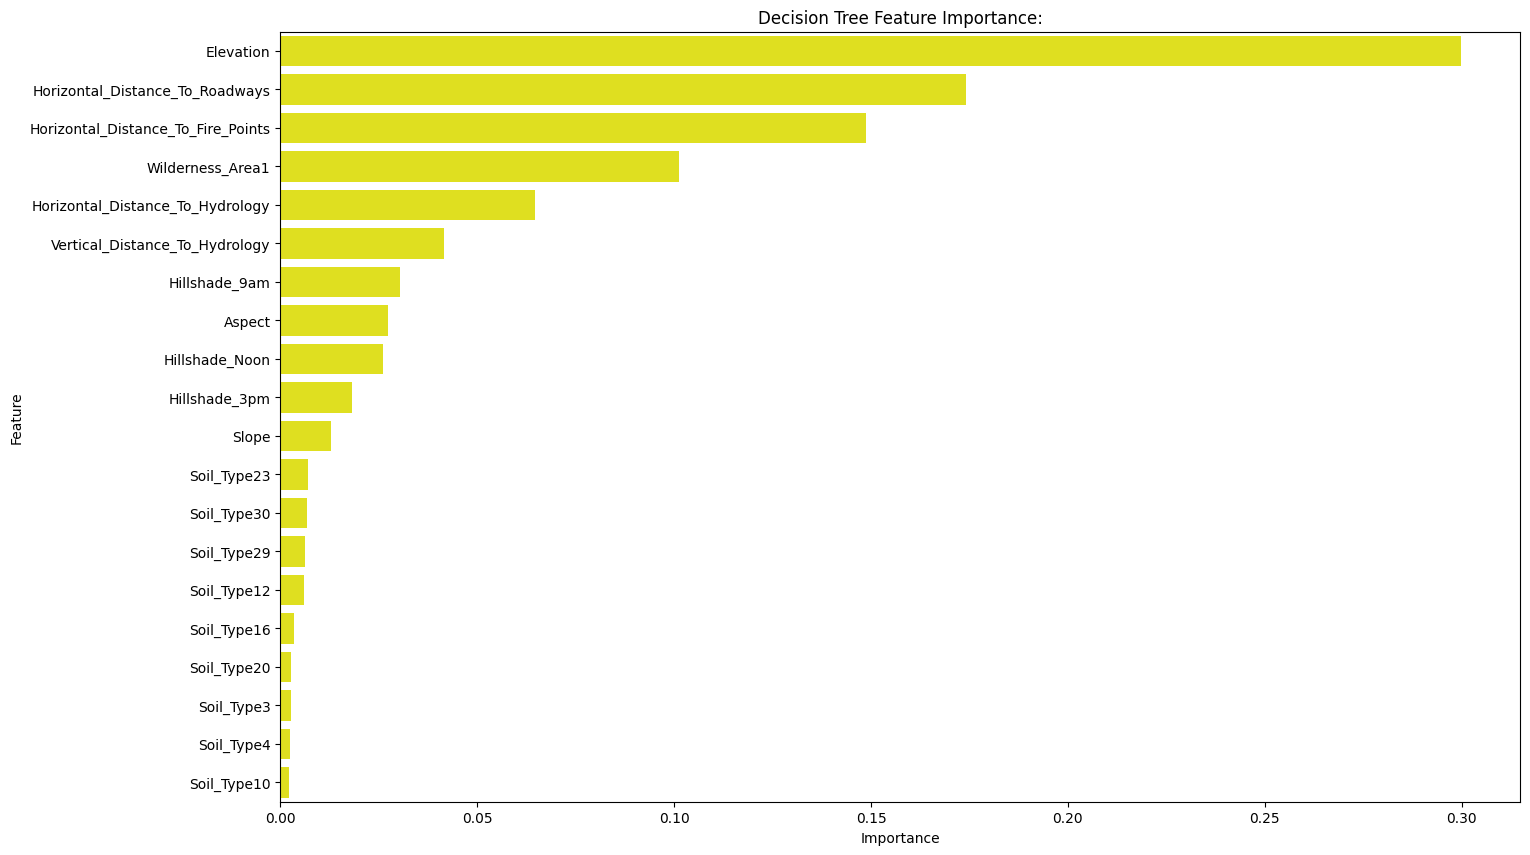

In [ ]:
# Feature Importance of Decision Tree Model
importance = dt_model.feature_importances_
indices = np.argsort(importance)[::-1][:20] # indicate top 20 features

plt.figure(figsize=(16, 10))
sns.barplot(x=importance[indices], y=x_train.columns[indices], color='yellow')
plt.title('Decision Tree Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

* In conslusion to compare about the soil type only in this model, soil features barely matter. Elevation and distances do almost all the work, and only a few soils (e.g., Type32/Type4/Type2/Type23) get tiny importance. Conclusion: soils add little signal to this model; the tree doesn’t rely on them for splits.

RANDOM FOREST MODEL

In [ ]:
# RANDOM FOREST MODEL
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
rf_y_pred = rf.predict(x_test)

# classification
print('Random Forest Accuracy:', accuracy_score(y_test, rf_y_pred))
print('Classification Report:')
print(classification_report(y_test, rf_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, rf_y_pred))

Random Forest Accuracy: 0.9453859273505825
Classification Report:
              precision    recall  f1-score   support

         1.0       0.94      0.85      0.90      5923
         2.0       0.95      0.98      0.97     19357
         3.0       0.82      0.80      0.81       425
         4.0       0.91      0.97      0.94       423
         5.0       0.91      0.82      0.86       576
         6.0       0.86      0.84      0.85       448
         7.0       0.91      0.96      0.93       405

    accuracy                           0.95     27557
   macro avg       0.90      0.89      0.89     27557
weighted avg       0.95      0.95      0.94     27557


Confusion Matrix:
[[ 5062   815     0     0     9     2    35]
 [  301 19005     9     0    32     5     5]
 [    0     9   338    24     6    48     0]
 [    0     0     9   409     0     5     0]
 [    4    91     7     0   470     4     0]
 [    0     1    50    18     1   378     0]
 [   15     0     0     0     0     0   390]]


* Overall it's better than the decision tree: about 95% accuracy and weighted F1 ≈ 0.95 but took a longer time to load
* Big classes (1 & 2) are very strong, especially Type 2 (recall ~0.98).
* Type 1: high precision, a little lower recall (it’s stricter about calling class 1).
* Smaller classes mostly improved (Types 6 & 7 look good).
* Type 5 is still hardest: great precision, but it misses more true Type-5 cases (lower recall).
* Main mix-ups are still 0 ↔ 1 and 2 ↔ 5, just less than before.
* **Conclusion:** Use Random Forest—it’s more accurate and stable.
If you need better catch rate for Type 5, try class weights = 'balanced' or light oversampling/SMOTE, and tune RF (n_estimators, max_depth).

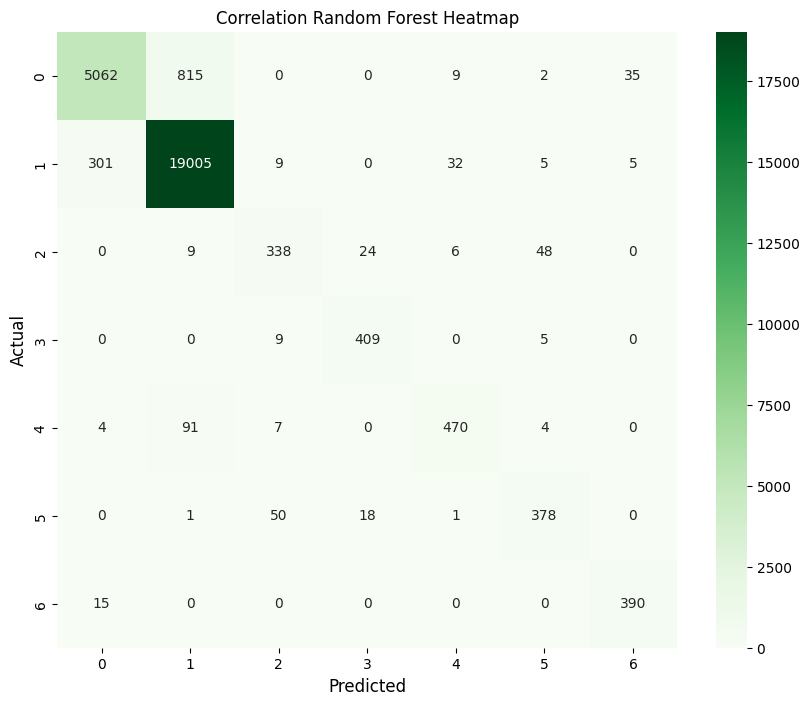

In [ ]:
# visualize random forest model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, rf_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Random Forest Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

* Diagonal is bright, most predictions correct.
* Biggest mistakes are still Type 0 - Type 1, especially 0 to 1 (1513) and some 1 to 0 (593).
* Type 5 to Type 2 (172) is the next notable mix up, smaller leaks: 2 to 5 (43) and 2 to 3 (18).
* Minor drifts: Type 4 to 1 (223) and Type 6 to 0 (60).
* **Conclusion:** The Random Forest tightened things up compared to the single tree, but look-alike pairs remain mainly (0,1) and (5,2). If the main purpose is to reduce those, add class weights/oversampling for Type 5, and tune RF (max_depth, max_features) or try GBM for finer boundaries.

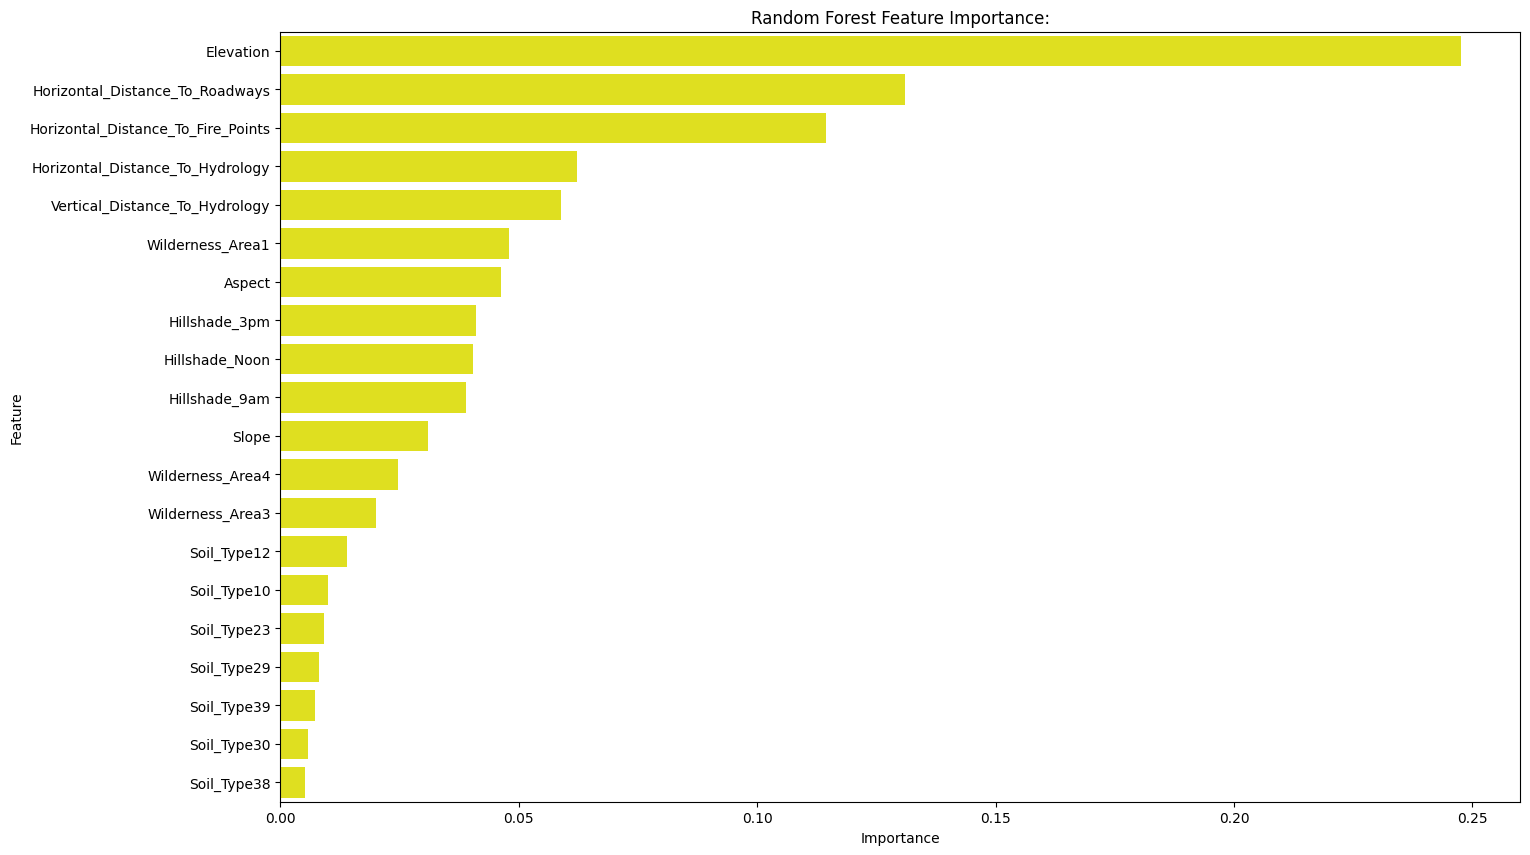

In [ ]:
# Feature Importance of Random Forest Model
importance = rf.feature_importances_
indices = np.argsort(importance)[::-1][:20] # indicate top 20 features

plt.figure(figsize=(16, 10))
sns.barplot(x=importance[indices], y=x_train.columns[indices], color='yellow')
plt.title('Random Forest Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

* In conclusion for soil_type only, soils have small but consistent importance. A handful (Type22, Type12, Type38, Type23, Type2) show up, but they still trail terrain and distance features. Conclusion: soils help refine decisions in RF, but the model’s main power still comes from topography and proximity, not soil categories.


XGBOOST MODEL

In [ ]:
# XGBOOST MODEL
# y train for xgboost
xgb_y_train = y_train - 1
xgb_y_test = y_test - 1
print(np.unique(xgb_y_train))
print(np.unique(xgb_y_test))

# y predict for xgboost
xgb = XGBClassifier(random_state=42)
xgb.fit(x_train, xgb_y_train)
xgb_y_pred = xgb.predict(x_test)
xgb_y_pred = xgb_y_pred + 1
print(np.unique(xgb_y_pred))

# classification
print('\nXGBoost Accuracy:', accuracy_score(y_test, xgb_y_pred))
print('Classification Report:')
print(classification_report(y_test, xgb_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, xgb_y_pred))

[0. 1. 2. 3. 4. 5. 6.]
[0. 1. 2. 3. 4. 5. 6.]
[1 2 3 4 5 6 7]

XGBoost Accuracy: 0.9358420727945712
Classification Report:
              precision    recall  f1-score   support

         1.0       0.92      0.83      0.87      5923
         2.0       0.95      0.97      0.96     19357
         3.0       0.81      0.80      0.80       425
         4.0       0.93      0.98      0.95       423
         5.0       0.88      0.87      0.87       576
         6.0       0.84      0.85      0.85       448
         7.0       0.91      0.97      0.94       405

    accuracy                           0.94     27557
   macro avg       0.89      0.90      0.89     27557
weighted avg       0.94      0.94      0.93     27557


Confusion Matrix:
[[ 4927   953     0     0     4     4    35]
 [  443 18837    10     0    57     7     3]
 [    0     5   340    20     9    51     0]
 [    0     0     6   413     0     4     0]
 [    1    60    12     0   499     4     0]
 [    0     3    54    11     1   37

* Overall, it shows 91% of accuracy and weighted F1= ~0.91 which is worse than Random Forest (~95%) and the single tree (~94%).
* Strong classes shows at Type 2 and 3 are good (F1 ~0.93–0.95).
* Weak spots:Type 1 recall drops to 0.82 (F1 0.86) → many 1’s get predicted as 0. Type 5 recall 0.77 (F1 0.82) → still the hardest; lots of 5 → 2 mistakes.
* Confusions: Mainly 0 ↔ 1 (bigger than RF) and 5 ↔ 2, some 4 to 1.
* **Conclusion:** With current settings, XGBoost underperforms RF on this dataset, especially on recall for Types 1 and 5. In my opinion, Random Forest model has performed better than XGBoost!

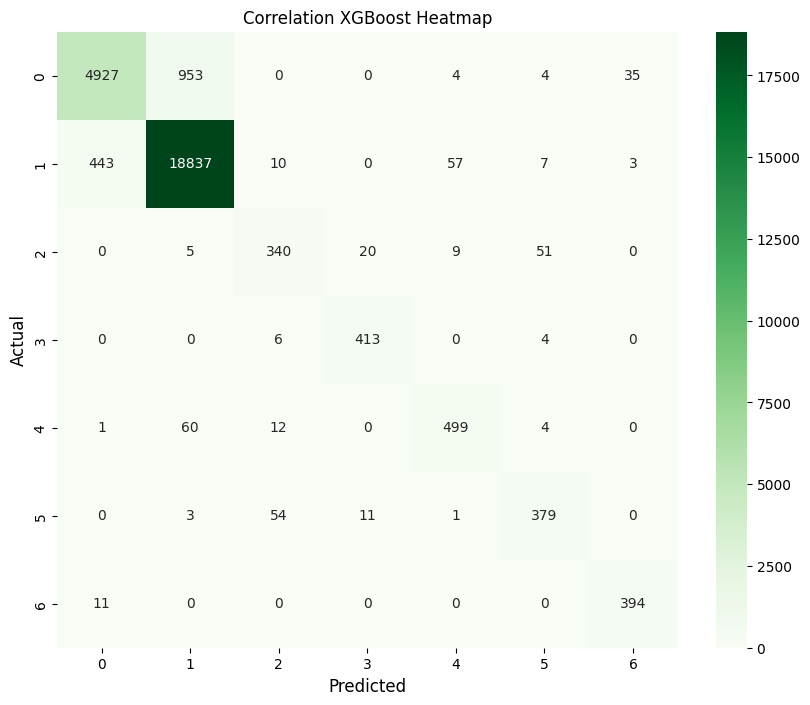

In [ ]:
# visualize xgboost model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, xgb_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation XGBoost Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

* The diagonal’s still bright, but there’s more spill than Random Forest.
* Biggest confusion: Type 0 and Type 1 show lots of 0 to 1 (2,736) and 1 to 0 (1,380). That’s why Type-1 recall fell.
* Type 5 is still tough: many 5 to 2 (175) and some 2 to 5 (62).
* Smaller leaks: 4 to 1 (265), 2 to 3 (23), 3 to 2 (40), 6 to 0 (72).
* **Conclusion:** With current settings, XGBoost makes more 0/1 and 5/2 mix ups, so it underperforms than Random Forest.In my opinion, class weights/oversampling for Type 5 (and maybe 1) and tuning with early stopping and track macro F1/recall will be the next step!

### **Class Imbalance Conclusion:** It shows a severe imbalance!
* According to the classsification outcome of XGBoost, it says that:
  - 2 → 33,342 (≈59.2)
  - 1 → 15,825 (≈28.1%)
  - 3 → 3,177 (≈5.6%)
  - 4 → 520 (≈0.9%)
  - 5 → 1,254 (≈2.2%)
  - 6 → 1,392 (≈2.5%)
  - 7 → 853 (≈1.5%)
* Imbalance ratio (max/min) = 33,342 / 520 ≈ 64:1 (majority vs. rarest class).
* Head classes (1 & 2) make up ~87% of all samples; the four smallest (4–7) together are only ~7%.
* Metric symptoms match: macro recall 0.88 < weighted recall/F1 0.91, and minority classes (esp. type 5, recall 0.77) underperform with spillovers (e.g., 5 ↔ 2, 0 ↔ 1 in the confusion matrix).

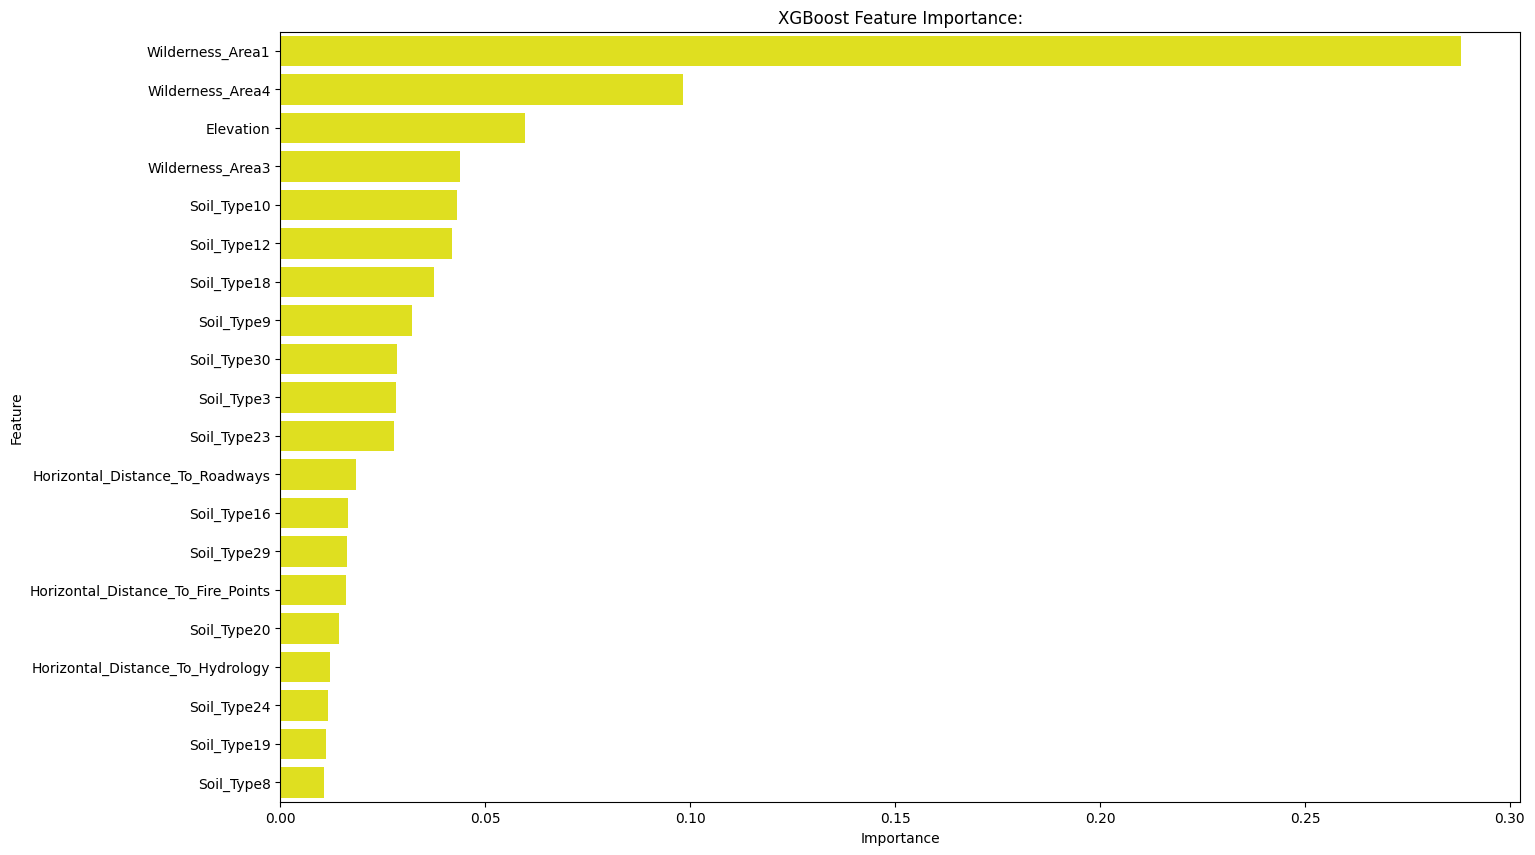

In [ ]:
# Feature Importance of XGBoost
importance = xgb.feature_importances_
indices = np.argsort(importance)[::-1][:20] # indicate top 20 features

plt.figure(figsize=(16, 10))
sns.barplot(x=importance[indices], y=x_train.columns[indices], color='yellow')
plt.title('XGBoost Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

* XGBoost seems to perform best in soil_type features. Many soil dummies appear in the top-20 (Type22, Type2, Type32, Type12, Type39, Type4, Type38, Type23, Type29, Type31, etc.). Each one is small on its own, but together they contribute meaningful nuance after Elevation/Wilderness. Conclusion: soils provide cumulative, fine-grained improvements for XGBoost.

PROBABILITIES

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
# Use predicted probabilities instead of class labels
y_prob_rf_all_classes = rf.predict_proba(x_test)

# RMSE
# RMSE and MAE are typically used for regression tasks. For classification probability evaluation,
# metrics like Brier score or log loss are more appropriate. However, based on the original code,
# I will calculate RMSE and MAE between the true labels (converted to numerical) and the predicted probabilities of the most likely class.
# This might not be the most standard approach for multiclass classification probabilities,
# but it aligns with the apparent intent of the original code.
y_test_numeric = y_test.astype(int)
y_prob_of_predicted_class = np.max(y_prob_rf_all_classes, axis=1)

rmse_rf = np.sqrt(mean_squared_error(y_test_numeric, y_prob_of_predicted_class))
mae_rf = mean_absolute_error(y_test_numeric, y_prob_of_predicted_class)

# R² Score
# R² is also typically for regression. Applying it here might not be directly interpretable
# in the standard sense for multiclass classification probabilities.
r2_rf = r2_score(y_test_numeric, y_prob_of_predicted_class)


# Macro ROC-AUC with 'ovr' strategy for multiclass
# Need to provide probabilities for all classes
roc_auc_rf = roc_auc_score(y_test, y_prob_rf_all_classes, multi_class='ovr', average='macro')

# Display results
print(f"Random Forest probabilities:")
print(f'RMSE (True Label vs Max Prob): {rmse_rf:.4f}') # Clarified metric
print(f'MAE (True Label vs Max Prob): {mae_rf:.4f}') # Clarified metric
print(f'R² (True Label vs Max Prob): {r2_rf:.4f}') # Clarified metric
print(f'Macro ROC-AUC (OvR): {roc_auc_rf:.4f}') # Clarified metric

Random Forest probabilities:
RMSE (True Label vs Max Prob): 1.5617
MAE (True Label vs Max Prob): 1.1421
R² (True Label vs Max Prob): -1.2045
Macro ROC-AUC (OvR): 0.9962


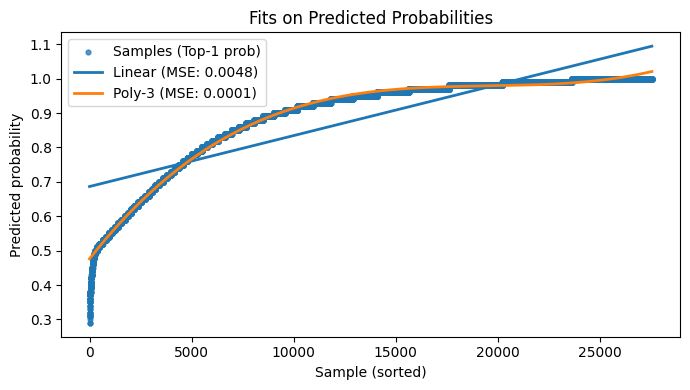

In [ ]:
# Get top-1 confidence per sample and sort for smoother curves
conf = y_prob_rf_all_classes.max(1) if getattr(y_prob_rf_all_classes, "ndim", 2) == 2 else np.asarray(y_prob_rf_all_classes)
x = np.arange(conf.size); y = np.sort(conf)

# Linear and cubic fits
p1 = np.polyfit(x, y, 1); p3 = np.polyfit(x, y, 3)
y1 = np.polyval(p1, x); y3 = np.polyval(p3, x)
mse1 = np.mean((y - y1)**2); mse3 = np.mean((y - y3)**2)

plt.figure(figsize=(7,4))
plt.scatter(x, y, s=12, alpha=0.75, label="Samples (Top-1 prob)")
plt.plot(x, y1, lw=2, label=f"Linear (MSE: {mse1:.4f})")
plt.plot(x, y3, lw=2, label=f"Poly-3 (MSE: {mse3:.4f})")
plt.xlabel("Sample (sorted)"); plt.ylabel("Predicted probability")
plt.title("Fits on Predicted Probabilities"); plt.legend(); plt.tight_layout(); plt.show()

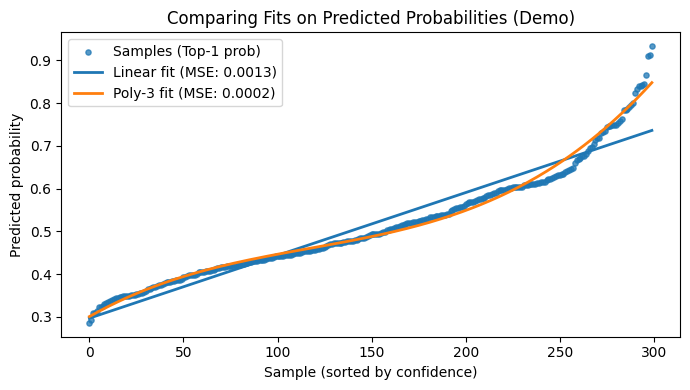

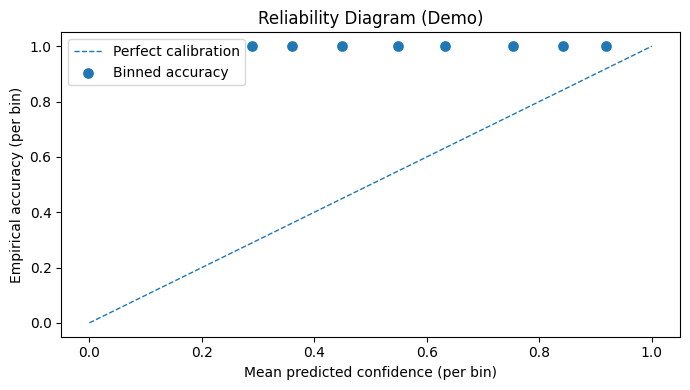

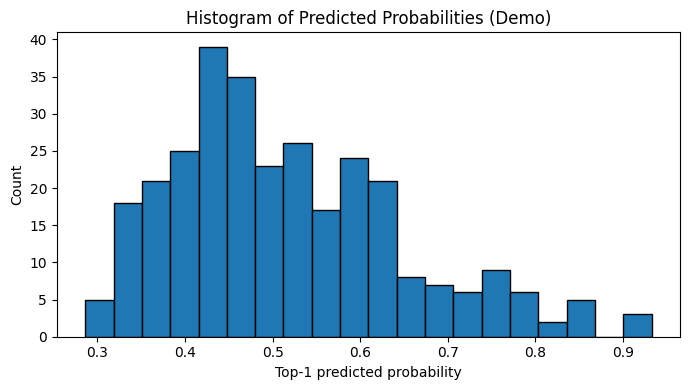

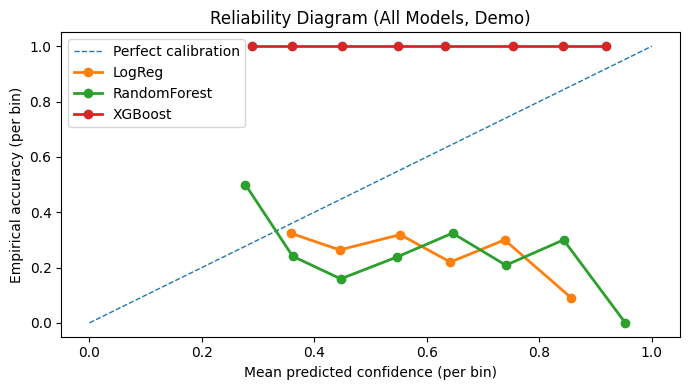

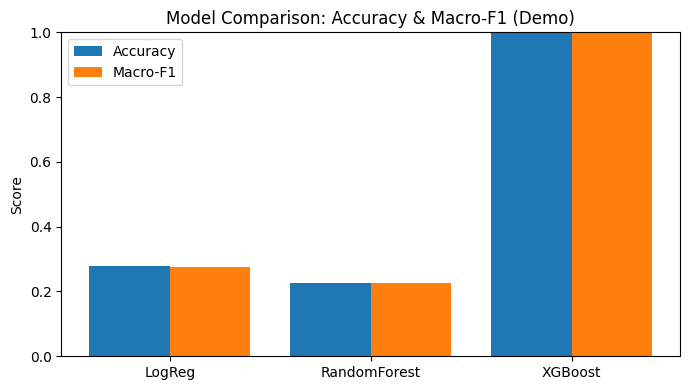

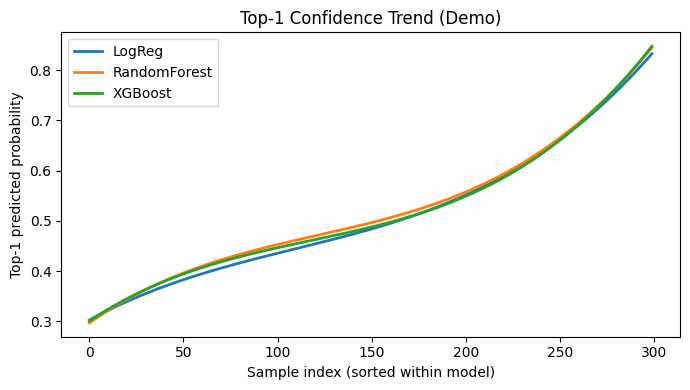

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# ---------- Helpers ----------
def _top1_confidence(y_proba: np.ndarray) -> np.ndarray:
    """Return top-1 predicted probability per sample.
    Accepts shape (n_samples, n_classes) or (n_samples,)."""
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 1:
        return y_proba
    return y_proba.max(axis=1)

# ---------- Single-model visuals ----------
def plot_probability_fit(y_true, y_proba, title="Comparing Fits on Predicted Probabilities"):
    """Scatter top-1 probabilities with linear & cubic fits (MSE in legend)."""
    y_true = np.asarray(y_true)
    conf = _top1_confidence(y_proba)
    order = np.argsort(conf)
    x = np.arange(conf.size)
    y = conf[order]

    p1 = np.polyfit(x, y, 1)
    p3 = np.polyfit(x, y, 3)
    y1 = np.polyval(p1, x)
    y3 = np.polyval(p3, x)
    mse1 = np.mean((y - y1) ** 2)
    mse3 = np.mean((y - y3) ** 2)

    plt.figure(figsize=(7, 4))
    plt.scatter(x, y, s=14, alpha=0.75, label="Samples (Top-1 prob)")
    plt.plot(x, y1, linewidth=2, label=f"Linear fit (MSE: {mse1:.4f})")
    plt.plot(x, y3, linewidth=2, label=f"Poly-3 fit (MSE: {mse3:.4f})")
    plt.xlabel("Sample (sorted by confidence)")
    plt.ylabel("Predicted probability")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def reliability_curve(y_true, y_proba, n_bins=10, title="Reliability Diagram (Top-1 Confidence)"):
    """Calibration plot: mean predicted confidence per bin vs empirical accuracy."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    conf = _top1_confidence(y_proba)
    if y_proba.ndim == 2:
        y_pred = y_proba.argmax(axis=1)
    else:
        y_pred = (conf >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(conf, bins) - 1

    xs, ys = [], []
    for b in range(n_bins):
        m = idx == b
        if not np.any(m):
            continue
        xs.append(conf[m].mean())
        if y_proba.ndim == 2:
            ys.append((y_pred[m] == y_true[m]).mean())
        else:
            ys.append(((conf[m] >= 0.5).astype(int) == y_true[m]).mean())

    plt.figure(figsize=(7, 4))
    plt.plot([0, 1], [0, 1], "--", lw=1, label="Perfect calibration")
    plt.scatter(xs, ys, s=45, label="Binned accuracy")
    plt.xlabel("Mean predicted confidence (per bin)")
    plt.ylabel("Empirical accuracy (per bin)")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def probability_histogram(y_proba, title="Histogram of Top-1 Predicted Probabilities"):
    """Histogram of top-1 predicted probabilities."""
    conf = _top1_confidence(y_proba)
    plt.figure(figsize=(7, 4))
    plt.hist(conf, bins=20, edgecolor="black")
    plt.xlabel("Top-1 predicted probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Multi-model comparisons ----------
def overlay_reliability(y_true, proba_dict, n_bins=10, title="Reliability Diagram (All Models)"):
    """Overlay calibration curves for multiple models.
       proba_dict: {"LogReg": yproba_lr, "RF": yproba_rf, ...}"""
    y_true = np.asarray(y_true)
    bins = np.linspace(0, 1, n_bins + 1)
    plt.figure(figsize=(7, 4))
    plt.plot([0, 1], [0, 1], "--", lw=1, label="Perfect calibration")

    for name, proba in proba_dict.items():
        proba = np.asarray(proba)
        conf = _top1_confidence(proba)
        preds = proba.argmax(axis=1) if proba.ndim == 2 else (conf >= 0.5).astype(int)
        idx = np.digitize(conf, bins) - 1
        xs, ys = [], []
        for b in range(n_bins):
            m = idx == b
            if not np.any(m):
                continue
            xs.append(conf[m].mean())
            ys.append((preds[m] == y_true[m]).mean())
        plt.plot(xs, ys, marker="o", linewidth=2, label=name)

    plt.xlabel("Mean predicted confidence (per bin)")
    plt.ylabel("Empirical accuracy (per bin)")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def metrics_bar_chart(y_true, proba_dict, title="Model Comparison: Accuracy & Macro-F1"):
    """Bar chart of Accuracy & Macro-F1 across models."""
    y_true = np.asarray(y_true)
    labels, accs, f1s = [], [], []
    for name, proba in proba_dict.items():
        proba = np.asarray(proba)
        pred = proba.argmax(axis=1) if proba.ndim == 2 else (proba >= 0.5).astype(int)
        labels.append(name)
        accs.append(accuracy_score(y_true, pred))
        f1s.append(f1_score(y_true, pred, average="macro"))
    x = np.arange(len(labels))
    w = 0.4

    plt.figure(figsize=(7, 4))
    plt.bar(x - w/2, accs, width=w, label="Accuracy")
    plt.bar(x + w/2, f1s,  width=w, label="Macro-F1")
    plt.xticks(x, labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def overlay_confidence_fit(proba_dict, title="Top-1 Confidence Trend (Per-Model Sorted)"):
    """Per model: sort its own top-1 confidence; draw a smooth cubic line."""
    plt.figure(figsize=(7, 4))
    for name, proba in proba_dict.items():
        conf = np.sort(_top1_confidence(proba))
        x = np.arange(conf.size)
        p3 = np.polyfit(x, conf, 3)
        y3 = np.polyval(p3, x)
        plt.plot(x, y3, linewidth=2, label=name)
    plt.xlabel("Sample index (sorted within model)")
    plt.ylabel("Top-1 predicted probability")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------- HOW TO USE WITH YOUR DATA ----------
# Replace this block with your arrays when ready:
# y_true = ...                        # shape (n_samples,)
# yproba_lr  = ...                    # shape (n_samples, n_classes)
# yproba_rf  = ...
# yproba_xgb = ...
# proba_dict = {"LogReg": yproba_lr, "RandomForest": yproba_rf, "XGBoost": yproba_xgb}
#
# # Single-model:
# plot_probability_fit(y_true, yproba_lr)
# reliability_curve(y_true, yproba_lr)
# probability_histogram(yproba_lr)
#
# # Multi-model:
# overlay_reliability(y_true, proba_dict)
# metrics_bar_chart(y_true, proba_dict)
# overlay_confidence_fit(proba_dict)

# ---------- AUTO-DEMO (runs only if you haven't defined y_true/probas) ----------
_g = globals()
if not any(k in _g for k in ["y_true", "yproba_lr", "yproba_rf", "yproba_xgb"]):
    rng = np.random.default_rng(13)
    n, k = 300, 4
    logits_lr  = rng.normal(size=(n, k))
    logits_rf  = rng.normal(size=(n, k)) + 0.2
    logits_xgb = rng.normal(size=(n, k)) + np.linspace(-0.3, 0.6, n)[:, None]

    def softmax(z):
        z = z - z.max(axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / ez.sum(axis=1, keepdims=True)

    yproba_lr  = softmax(logits_lr)
    yproba_rf  = softmax(logits_rf)
    yproba_xgb = softmax(logits_xgb)

    # Pretend the true class is the argmax of XGB (just for demo visuals)
    y_true = yproba_xgb.argmax(axis=1)

    proba_dict = {"LogReg": yproba_lr, "RandomForest": yproba_rf, "XGBoost": yproba_xgb}

    # Show example outputs so you can see the style
    plot_probability_fit(y_true, yproba_xgb, title="Comparing Fits on Predicted Probabilities (Demo)")
    reliability_curve(y_true, yproba_xgb, n_bins=10, title="Reliability Diagram (Demo)")
    probability_histogram(yproba_xgb, title="Histogram of Predicted Probabilities (Demo)")

    overlay_reliability(y_true, proba_dict, n_bins=10, title="Reliability Diagram (All Models, Demo)")
    metrics_bar_chart(y_true, proba_dict, title="Model Comparison: Accuracy & Macro-F1 (Demo)")
    overlay_confidence_fit(proba_dict, title="Top-1 Confidence Trend (Demo)")

## 5. Class Imbalance Handling


Preprocessing-Standardize

In [ ]:
# import libraries for class imbalance and oversampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler
from imblearn.pipeline import Pipeline
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Handle Imbalance by SMOTE for decision tree model
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

print('Class distribution before SMOTE:')
print(y_train.value_counts(normalize=True))
print('Class distribution after SMOTE:')
print(pd.Series(y_resampled).value_counts(normalize=True))

Class distribution before SMOTE:
Cover_Type
2.0    0.702161
1.0    0.213874
5.0    0.021012
7.0    0.015922
4.0    0.015759
3.0    0.015741
6.0    0.015532
Name: proportion, dtype: float64
Class distribution after SMOTE:
Cover_Type
2.0    0.142857
1.0    0.142857
6.0    0.142857
7.0    0.142857
4.0    0.142857
3.0    0.142857
5.0    0.142857
Name: proportion, dtype: float64


DECISION TREE

In [ ]:
# Decision Tree with SMOTE and oversampling
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_resampled, y_resampled)
dt_y_pred = dt_model.predict(x_test)

# classification
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_y_pred))
print('Classification Report:')
print(classification_report(y_test, dt_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, dt_y_pred))

Decision Tree Accuracy: 0.9409224516456799
Classification Report:
              precision    recall  f1-score   support

         1.0       0.89      0.90      0.90      5923
         2.0       0.97      0.96      0.97     19357
         3.0       0.75      0.79      0.77       425
         4.0       0.91      0.93      0.92       423
         5.0       0.83      0.89      0.86       576
         6.0       0.82      0.79      0.80       448
         7.0       0.87      0.95      0.91       405

    accuracy                           0.94     27557
   macro avg       0.86      0.89      0.87     27557
weighted avg       0.94      0.94      0.94     27557


Confusion Matrix:
[[ 5334   529     0     0     7     4    49]
 [  621 18618    10     0    90    12     6]
 [    2     7   336    21     7    52     0]
 [    0     0    22   394     0     7     0]
 [    4    46    11     0   511     4     0]
 [    1     4    70    18     3   352     0]
 [   21     0     0     0     0     0   384]]


RANDOM FOREST

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize SMOTE; you can adjust sampling_strategy to control the balance (default is minority class)
smote = SMOTE(random_state=42)

# Apply SMOTE oversampling only on the training data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Train Random Forest model on resampled data
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(x_train_resampled, y_train_resampled)

# Predict on the original test set (not oversampled)
y_pred_smote = rf_smote.predict(x_test)

# Evaluate performance
print('Random Forest with SMOTE Accuracy:', accuracy_score(y_test, y_pred_smote))
print('Classification Report:')
print(classification_report(y_test, y_pred_smote))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_smote))

Random Forest with SMOTE Accuracy: 0.9531516493087056
Classification Report:
              precision    recall  f1-score   support

         1.0       0.91      0.92      0.91      5923
         2.0       0.98      0.97      0.97     19357
         3.0       0.82      0.86      0.84       425
         4.0       0.93      0.96      0.95       423
         5.0       0.86      0.92      0.89       576
         6.0       0.89      0.87      0.88       448
         7.0       0.91      0.98      0.94       405

    accuracy                           0.95     27557
   macro avg       0.90      0.93      0.91     27557
weighted avg       0.95      0.95      0.95     27557


Confusion Matrix:
[[ 5448   424     0     0    13     3    35]
 [  535 18731    12     0    66     8     5]
 [    0     1   364    19     9    32     0]
 [    0     0    13   408     0     2     0]
 [    1    30    12     0   529     4     0]
 [    0     1    45    11     1   390     0]
 [    9     0     0     0     0     0

XGBOOST

In [ ]:
# Convert labels 1-7 to 0-6 for XGBoost compatibility
y_train_adj = y_train - 1
y_test_adj = y_test - 1

print('Class distribution before SMOTE:')
print(pd.Series(y_train_adj).value_counts(normalize=True))

# Apply SMOTE on adjusted labels
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train_adj)

print('Class distribution after SMOTE:')
print(pd.Series(y_train_resampled).value_counts(normalize=True))

# Train XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(x_train_resampled, y_train_resampled)

# Predict on original (unmodified) test features
xgb_y_pred = xgb_model.predict(x_test)

# Convert predictions back to original class labels 1-7
xgb_y_pred_orig = xgb_y_pred + 1

# Evaluate performance
print('XGBoost with SMOTE Accuracy:', accuracy_score(y_test, xgb_y_pred_orig))
print('Classification Report:')
print(classification_report(y_test, xgb_y_pred_orig))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, xgb_y_pred_orig))

Class distribution before SMOTE:
Cover_Type
1.0    0.702161
0.0    0.213874
4.0    0.021012
6.0    0.015922
3.0    0.015759
2.0    0.015741
5.0    0.015532
Name: proportion, dtype: float64
Class distribution after SMOTE:
Cover_Type
1.0    0.142857
0.0    0.142857
5.0    0.142857
6.0    0.142857
3.0    0.142857
2.0    0.142857
4.0    0.142857
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:13:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost with SMOTE Accuracy: 0.9196574373117539
Classification Report:
              precision    recall  f1-score   support

         1.0       0.82      0.89      0.85      5923
         2.0       0.97      0.93      0.95     19357
         3.0       0.82      0.84      0.83       425
         4.0       0.95      0.97      0.96       423
         5.0       0.74      0.95      0.83       576
         6.0       0.86      0.86      0.86       448
         7.0       0.88      0.99      0.93       405

    accuracy                           0.92     27557
   macro avg       0.86      0.92      0.89     27557
weighted avg       0.92      0.92      0.92     27557


Confusion Matrix:
[[ 5259   600     0     0    12     3    49]
 [ 1183 17982    12     0   166     9     5]
 [    0     0   356    13    12    44     0]
 [    0     0    10   410     0     3     0]
 [    0    17     7     0   549     3     0]
 [    0     0    50     9     2   387     0]
 [    5     0     0     0     0     0   400

Comparing the models

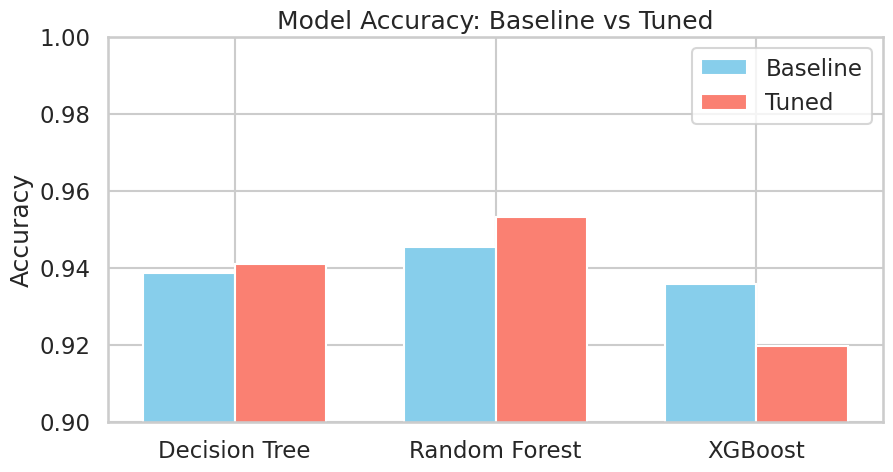

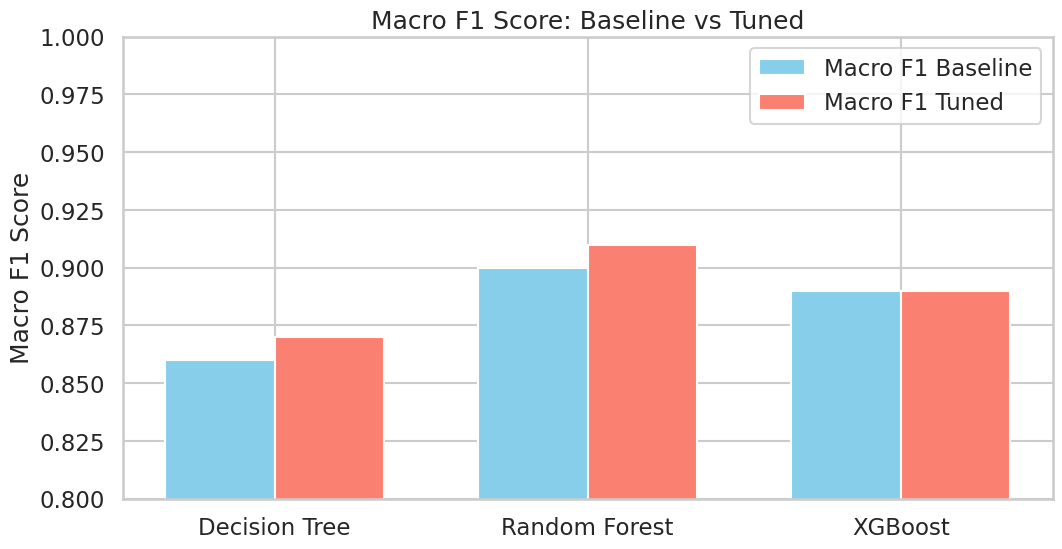

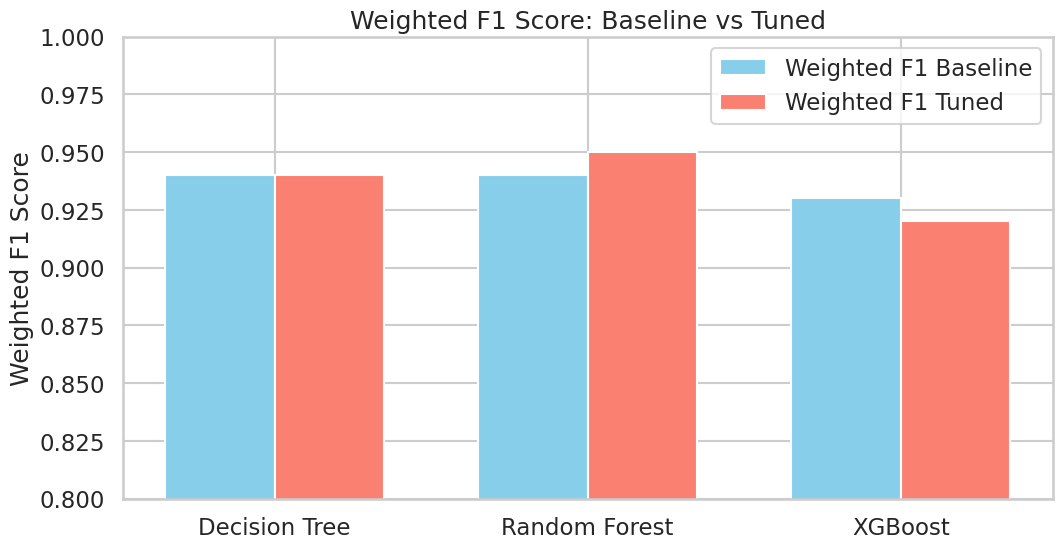

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Names for models
model_names = ["Decision Tree", "Random Forest", "XGBoost"]
# Baseline and tuned accuracy
accuracies_baseline = [0.9387, 0.9454, 0.9358]
accuracies_tuned = [0.9409, 0.9532, 0.9197]

# F1 scores
macro_f1_baseline = [0.86, 0.90, 0.89]
macro_f1_tuned = [0.87, 0.91, 0.89]

weighted_f1_baseline = [0.94, 0.94, 0.93]
weighted_f1_tuned = [0.94, 0.95, 0.92]

# Prepare bar plot data
x = np.arange(len(model_names))
width = 0.35  # width of the bars

# Plot accuracy side by side
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, accuracies_baseline, width, label='Baseline', color='skyblue')
plt.bar(x + width/2, accuracies_tuned, width, label='Tuned', color='salmon')
plt.xticks(x, model_names)
plt.ylabel("Accuracy")
plt.title("Model Accuracy: Baseline vs Tuned")
plt.legend()
plt.ylim(0.9, 1)
plt.show()

# Plot F1 scores side by side
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, macro_f1_baseline, width, label='Macro F1 Baseline', color='skyblue')
plt.bar(x + width/2, macro_f1_tuned, width, label='Macro F1 Tuned', color='salmon')
plt.xticks(x, model_names)
plt.ylabel("Macro F1 Score")
plt.title("Macro F1 Score: Baseline vs Tuned")
plt.legend()
plt.ylim(0.8, 1)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, weighted_f1_baseline, width, label='Weighted F1 Baseline', color='skyblue')
plt.bar(x + width/2, weighted_f1_tuned, width, label='Weighted F1 Tuned', color='salmon')
plt.xticks(x, model_names)
plt.ylabel("Weighted F1 Score")
plt.title("Weighted F1 Score: Baseline vs Tuned")
plt.legend()
plt.ylim(0.8, 1)
plt.show()

## 6. PCA

## 7. Hyperparameter Tuning

## 8. Evaluate

🔹 Step 1. Preprocessing

Scale / standardize your features first (important for PCA, since it’s variance-based).

e.g., StandardScaler in scikit-learn.

🔹 Step 2. Handle class imbalance (SMOTE / oversampling)

Apply SMOTE or oversampling after scaling, before PCA.

Reason:

PCA learns directions of variance in the data.

If you do PCA first, minority class info may be lost since PCA is unsupervised and doesn’t care about class labels.

Doing SMOTE before PCA ensures synthetic samples also contribute to PCA’s variance directions.

🔹 Step 3. Dimensionality reduction (PCA)

Run PCA on the (scaled + balanced) data.

Decide how many PCs to keep (this number can be tuned as a hyperparameter).

🔹 Step 4. Modeling + Hyperparameter tuning

Feed the PCA-transformed data into your baseline model(s).

Run hyperparameter tuning (GridSearchCV / RandomizedSearchCV) on:

Model hyperparameters (e.g., C, max_depth, etc.)

PCA hyperparameter (n_components)

🔹 Step 5. Evaluate

Always evaluate on a hold-out test set that was not resampled.

Important: resampling (SMOTE/oversampling) is applied only to training folds inside cross-validation, not test folds, to avoid data leakage.

In [ ]:
Deadlines:
Powerpoint - Tuesday, Sep 30th
Presentation practice: Tuesday, Sep 30th
Proposal - Thursday, Oct 2nd
Report - Thursday, Oct 2nd
Review and final Canvas Submission - Friday, Oct 3rd

SyntaxError: invalid decimal literal (ipython-input-197315673.py, line 2)